In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
from transformers import pipeline
import math
import torch
from transformers import AutoTokenizer, GPT2LMHeadModel, EsmForProteinFolding
import numpy as np
import pandas as pd
import argparse
import yaml
import os
import shutil
import gc
from tqdm import tqdm
from Bio import SeqIO

/home/b1607/anaconda3/envs/TF/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-06 18:39:53.498756: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-06 18:39:53.506708: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-06 18:39:53.518219: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-06 18:39:53.5

In [2]:
all_generated_clean = [
    str(record.seq)
    for record in SeqIO.parse("generated_clean.fasta", "fasta")
]

In [4]:
VALID_AA = set("ACDEFGHIKLMNPQRSTVWY")

all_generated_clean = [
    seq for seq in all_generated_clean
    if seq and all(aa in VALID_AA for aa in seq.upper())
]

In [5]:
all_generated_clean[:10]

['FACSFFCCFPRHKNP',
 'SDLNMIEKLPDSICE',
 'FDALFSKCVQHGHWP',
 'HCLAHFDNRASLASS',
 'PARPAGPPRAAAATA',
 'DVLRLFCQRCEHLQT',
 'HTSNHTRHHRPRCCP',
 'KMEMPFEYDFQYEIF',
 'RHHHSQQHNEEDTQP',
 'RPAWPSIAAVVLAVL']

In [10]:
# ppl function
def calculatePerplexity(sequence, model, tokenizer):
    input_ids = torch.tensor(tokenizer.encode(sequence)).unsqueeze(0)
    input_ids = input_ids.to(device)
    with torch.no_grad():
        outputs = model(input_ids, labels=input_ids)
    loss, logits = outputs[:2]

    return math.exp(loss)


print('Starting to order by perplexity...')

ppls = []
sequences_with_ppl = []

for sequence in tqdm(all_generated_clean):

    sequences_with_ppl.append(sequence)
    sequence = '<|endoftext|>' + sequence + '<|endoftext|>'
    ppl = calculatePerplexity(sequence, model, tokenizer)
    ppls.append(ppl)

Starting to order by perplexity...


100%|████████████████████████████████████| 66135/66135 [08:04<00:00, 136.63it/s]


In [11]:
#storing all generated proteins with their perplexity values in csv
df_ppl = pd.DataFrame()
df_ppl['Sequence'] = sequences_with_ppl
df_ppl['Perplexity'] = ppls

In [12]:
df_ppl.head()

,Sequence,Perplexity
0,FACSFFCCFPRHKNP,47281.259249
1,SDLNMIEKLPDSICE,603390.523560
2,FDALFSKCVQHGHWP,205415.099398
3,HCLAHFDNRASLASS,75102.436179
4,PARPAGPPRAAAATA,313239.143252


In [13]:
df_ppl.to_csv('./out/all_generated_with_perplexity.csv', index=False)

In [14]:
k = len(all_generated_clean)//3 #select top 1000 sequences with lowest perplexity
print(k)
top_peps = np.array(sequences_with_ppl)[np.argsort(ppls)[:k]]
top_peps = [i for i in top_peps if len(i) != 0]

22045


In [15]:
#checking if sequences are inside the hull
# Load the .npz file
data = np.load('./hull.npz')

df_valid = pd.DataFrame()
df_valid['Sequence'] = list(top_peps) #top one-third

def create_3d_point(sequence, c):
    # Step 1: Count the number of occurrences of character c
    normalized_chars = ['X','U','B','Z','O','J']

    for norm_char in normalized_chars:
        sequence = sequence.replace(norm_char, '')

    count_c = sequence.count(c)
    
    if count_c == 0:
        return [0, 0, 0]  # Return None if the character c is not found
    
    # Step 2: Calculate the mean distance from the start of all occurrences of c
    indices_c = [i for i, char in enumerate(sequence) if char == c]
    mean_distance = sum(indices_c) / count_c
    
    # Step 3: Compute the second normalized central moment of the distribution of c
    variance = sum((idx - mean_distance) ** 2 for idx in indices_c) / count_c
    second_moment = variance / (len(sequence))
    
    # Create the 3D vector
    point = [count_c, mean_distance, second_moment]
    
    return point

def point_in_hull(point, hull_equations, tolerance=1e-12):
    return all(
        (np.dot(eq[:-1], point) + eq[-1] <= tolerance)
        for eq in hull_equations)

# Iterate over all arrays inside the file
def check_validity(seq):
    inside_hulls = []
    for c in data.files:
        equations = data[c]
        point = create_3d_point(seq, c)
        inside_hulls.append(point_in_hull(point, equations))
    return all(inside_hulls)


print('Starting Protein Validity Check...')
df_valid['Valid Protein'] = [check_validity(seq) for seq in top_peps]

filtered_peps = [pep for pep in top_peps if check_validity(pep)]

print('Valid proteins identified.')

Starting Protein Validity Check...
Valid proteins identified.


In [16]:
len(filtered_peps)

20753

In [17]:
len(df_valid[df_valid['Valid Protein']==True])
# there are only 21223 peptides left

20753

In [18]:
del model
gc.collect()
torch.cuda.empty_cache()
print('Starting structure check...')
esm_model = EsmForProteinFolding.from_pretrained("facebook/esmfold_v1")
esm_tokenizer = AutoTokenizer.from_pretrained("facebook/esmfold_v1")

Starting structure check...


Some weights of EsmForProteinFolding were not initialized from the model checkpoint at facebook/esmfold_v1 and are newly initialized: ['esm.contact_head.regression.bias', 'esm.contact_head.regression.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [19]:
esm_model = esm_model.to(device)

plddt_results = []


for sequence in tqdm(top_peps):
    # Input the sequence to ESM model
    input_sequence = sequence.replace('\n', '')
    if len(input_sequence) == 0:
        continue
    inputs = esm_tokenizer([input_sequence], return_tensors="pt", add_special_tokens=False)
    inputs = inputs.to(device)
    outputs = esm_model(**inputs)
    avg_plddt = torch.mean(outputs.plddt)
    plddt_results.append(avg_plddt.item())
    torch.cuda.empty_cache()

100%|███████████████████████████████████| 22045/22045 [2:28:10<00:00,  2.48it/s]


In [20]:
df_valid['plDDT'] = plddt_results
plddt_results = np.array(plddt_results)
df_valid['Good Structure'] = list(plddt_results > 0.7)

In [21]:
df_valid.head()

,Sequence,Valid Protein,plDDT,Good Structure
0,NHHGNHHGNHHDNHH,True,0.510850,False
1,QQQQHQQQQHQQQQQ,True,0.679499,False
2,KHHENHHGNHHGNHH,True,0.524943,False
3,GGGRGGGGGGGGGGG,False,0.822335,True
4,QQQQQQPQQQPQQQQ,True,0.604837,False


In [22]:
count = df_valid[
    (df_valid["Valid Protein"] == True) &
    (df_valid["plDDT"] > 0.7) &
    (df_valid["Good Structure"] == True)
].shape[0]

print(count)

1678


In [23]:
#Save valid protein and structure check data to csv
df_good = df_valid[
    (df_valid["Valid Protein"] == True) &
    (df_valid["plDDT"] > 0.7) &
    (df_valid["Good Structure"] == True)
]
df_good.to_csv('./out/generation_checks_good.csv', index=False)

In [24]:
#Save valid protein and structure check data to csv
df_valid.to_csv('./out/generation_checks_all.csv', index=False)

In [50]:
import pandas as pd
from Bio import SeqIO

def map_csv_to_fasta(csv_file, fasta_source, fasta_output):
    print(f"Reading target sequences from {csv_file}...")
    # 1. Load the target sequences from CSV
    df = pd.read_csv(csv_file)
    
    # Clean sequences (remove whitespace) and convert to a list
    # We keep duplicates in the list if you want the output to match the CSV rows 1-to-1
    target_seqs_list = df['Sequence'].dropna().astype(str).str.strip().tolist()
    target_seqs_set = set(target_seqs_list) # For fast lookup check

    print(f"Building lookup map from {fasta_source}...")
    # 2. Create a dictionary mapping { Sequence_String : Header_ID } from the source FASTA
    seq_to_id = {}
    # SeqIO handles multi-line FASTA correctly
    for record in SeqIO.parse(fasta_source, "fasta"):
        seq_str = str(record.seq).strip()
        # Only store if it's one of the sequences we are looking for (saves memory)
        if seq_str in target_seqs_set:
            seq_to_id[seq_str] = record.description # .description gives full header, .id gives ID only

    print(f"Writing matches to {fasta_output}...")
    # 3. Write to the new FASTA file
    found_count = 0
    missing_count = 0
    
    with open(fasta_output, "w") as out_f:
        for seq in target_seqs_list:
            if seq in seq_to_id:
                # Write: >Header \n Sequence
                out_f.write(f">{seq_to_id[seq]}\n{seq}\n")
                found_count += 1
            else:
                missing_count += 1
                # Optional: Print missing sequences
                # print(f"Warning: Sequence not found in FASTA source: {seq[:20]}...")

    print(f"------------------------------------------------")
    print(f"Process Complete.")
    print(f"Matches found and written: {found_count}")
    print(f"Sequences missing from FASTA: {missing_count}")
    print(f"Output saved to: {fasta_output}")


map_csv_to_fasta(
        csv_file="./out/generation_checks_good.csv",
        fasta_source="generated_clean.fasta",
        fasta_output="./out/generation_checks_good.fasta"
    )

Reading target sequences from ./out/generation_checks_good.csv...
Building lookup map from generated_clean.fasta...
Writing matches to ./out/generation_checks_good.fasta...
------------------------------------------------
Process Complete.
Matches found and written: 1678
Sequences missing from FASTA: 0
Output saved to: ./out/generation_checks_good.fasta


In [26]:
seq = "FACSFFCCFPRHKNP"
pa = ProteinAnalysis(seq)
pa

In [48]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from collections import Counter
import numpy as np

def compute_physchem(seq, n_term="H", c_term="OH"):
    """
    Calculates properties with support for N/C-terminal modifications.
    n_term: "H" (Free Amine), "Ac" (Acetyl), "Pyr" (Pyroglutamate)
    c_term: "OH" (Free Acid), "NH2" (Amide)
    """
    if not seq or not isinstance(seq, str):
        return None
    
    pa = ProteinAnalysis(seq)
    
    # 1. Calculate Base Charge (Side Chains Only)
    # We calculate pH 7.4 charge manually to exclude termini first
    pKa_sidechains = {'K': 10.53, 'R': 12.48, 'H': 6.00, 'D': 3.86, 'E': 4.25, 'C': 8.33, 'Y': 10.07}
    pH = 7.0
    charge = 0.0
    
    # Side chain charges
    for aa, pKa in pKa_sidechains.items():
        count = seq.count(aa)
        if aa in ['K', 'R', 'H']: # Bases (Positive)
            charge += count * (1 / (1 + 10**(pH - pKa)))
        else: # Acids (Negative)
            charge -= count * (1 / (1 + 10**(pKa - pH)))

    # 2. Add N-Terminus Charge
    if n_term == "H":  # Free Amine (Default)
        pKa_N = 9.69
        charge += 1 / (1 + 10**(pH - pKa_N))
    elif n_term in ["Ac", "Pyr", "Biotinyl"]:
        pass # Neutral (Charge = 0)

    # 3. Add C-Terminus Charge
    if c_term == "OH": # Free Acid (Default)
        pKa_C = 2.34
        charge -= 1 / (1 + 10**(pKa_C - pH))
    elif c_term == "NH2": # Amidation
        pass # Neutral (Charge = 0)

    # Standard Biopython calculations
    mw = pa.molecular_weight()
    gravy = pa.gravy()
    aromaticity = pa.aromaticity()
    instability_index = pa.instability_index()
    
    try:
        pI = pa.isoelectric_point()
    except Exception:
        pI = np.nan
    
    return {
        "length": len(seq),
        "mw": round(mw,2),
        "gravy": round(gravy,2),
        "aromaticity": round(aromaticity,2),
        "instability_index": round(instability_index,2),
        "pI": round(pI,2),
        "net_charge": round(charge,2)
    }

In [54]:
import os
import argparse
from Bio import SeqIO, pairwise2
from Bio.SeqUtils.ProtParam import ProteinAnalysis
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter


AA_ORDER = list("ACDEFGHIKLMNPQRSTVWY")

def seq_to_aa_comp(seq):
    c = Counter(seq)
    tot = len(seq)
    return [c.get(aa, 0) / tot if tot>0 else 0.0 for aa in AA_ORDER]


def best_identity_to_set(query_seq, target_seqs):
    """
    Compute best (max) percent identity between query_seq and any sequence in target_seqs.
    Uses global alignment (pairwise2.globalxx) and counts exact matches.
    Returns best_identity (0-1) and best_target_index.
    """
    best_identity = 0.0
    best_idx = -1
    for i, tgt in enumerate(target_seqs):
        # globalxx gives score = number of matches for the best alignment (no penalities)
        # but we need to compute percent identity = matches / aligned_length
        alns = pairwise2.align.globalxx(query_seq, tgt, one_alignment_only=True, score_only=False)
        if len(alns) == 0:
            continue
        # alns[0] is an Alignment object: (seqA, seqB, score, begin, end) or a tuple
        aln = alns[0]
        # depending on Biopython version, representation may vary; safer to call with score_only=True to get score
        # fallback: compute our own simple alignment with globalxx score_only
        score = pairwise2.align.globalxx(query_seq, tgt, score_only=True)
        # Need aligned length: since globalxx aligns full sequences with gaps,
        # aligned_length = max(len(query_seq), len(tgt)) + gaps introduced -> but globalxx returns matches only.
        # We'll compute percent identity as score / max(len(query_seq), len(tgt))
        denom = max(len(query_seq), len(tgt))
        if denom > 0:
            identity = score / denom
        else:
            identity = 0.0
        if identity > best_identity:
            best_identity = identity
            best_idx = i
    return best_identity, best_idx

def centroid_feature_vector(seqs):
    feats = []
    for s in seqs:
        comp = seq_to_aa_comp(s)
        phys = compute_physchem(s)
        fv = comp + [phys["length"], phys["mw"], phys["gravy"], phys["aromaticity"],
                     phys["instability_index"], phys["pI"], phys["net_charge"]]
        feats.append(fv)
    return np.nanmean(np.array(feats), axis=0)

def sequence_feature_vector(seq):
    comp = seq_to_aa_comp(seq)
    phys = compute_physchem(seq)
    fv = comp + [phys["length"], phys["mw"], phys["gravy"], phys["aromaticity"],
                 phys["instability_index"], phys["pI"], phys["net_charge"]]
    return np.array(fv)

def read_fasta_seqs(fasta_path):
    seqs = []
    ids = []
    for rec in SeqIO.parse(fasta_path, "fasta"):
        s = str(rec.seq).strip().upper()
        # ensure only standard amino acids; replace or skip unnatural chars
        s = "".join([c for c in s if c in "ACDEFGHIKLMNPQRSTVWY"])
        seqs.append(s)
        ids.append(rec.id)
    return ids, seqs

def write_top_n_fasta(ids, seqs, out_fasta, top_n=20):
    # write top_n sequences (first top_n entries)
    with open(out_fasta, "w") as fh:
        for i, (id_, seq) in enumerate(zip(ids, seqs)):
            if i >= top_n:
                break
            fh.write(f">{id_}\n{seq}\n")

In [58]:
print("Loading files...")
gen_ids, gen_seqs = read_fasta_seqs("./out/generation_checks_good.fasta")
esr_ids, esr_seqs = read_fasta_seqs("./esr1_antigens.fasta")

print(f"Loaded {len(gen_seqs)} generated sequences and {len(esr_seqs)} ESR1 antigen sequences.")


# Prepare centroid of ESR1 descriptors
print("Computing centroid feature vector of ESR1 antigens...")
esr_centroid = centroid_feature_vector(esr_seqs)  # numpy vector

# Precompute ESR1 descriptors optionally (for later use)
esr_fvs = [sequence_feature_vector(s) for s in esr_seqs]

# For each generated peptide compute descriptors and similarities
rows = []
for gid, gseq in tqdm(list(zip(gen_ids, gen_seqs)), desc="Analyzing generated peptides"):
    phys = compute_physchem(gseq)
    aa_comp = seq_to_aa_comp(gseq)
    fv = sequence_feature_vector(gseq).reshape(1,-1)

    # cosine similarity to ESR1 centroid
    cos_sim = float(cosine_similarity(fv, esr_centroid.reshape(1,-1))[0,0])

    # best percent identity to any ESR1 antigen (globalxx based)
    best_id, best_idx = best_identity_to_set(gseq, esr_seqs)
    best_target_id = esr_ids[best_idx] if best_idx >= 0 else None

    # exact match flag
    exact_match = gseq in esr_seqs

    # mutation flag: check if any of user-specified mutation substrings appear
    mutation_flag = False
    matched_mutations = []
    mutation_substrings = ["KRN","LQC","LPS","PHY","LSD","LND","YGL"]

    for mut in mutation_substrings:
        if mut.upper() in gseq:
            mutation_flag = True
            matched_mutations.append(mut)

    row = {
        "gen_id": gid,
        "sequence": gseq,
        "length": phys["length"],
        "mw": phys["mw"],
        "gravy": phys["gravy"],
        "aromaticity": phys["aromaticity"],
        "instability_index": phys["instability_index"],
        "pI": phys["pI"],
        "net_charge": phys["net_charge"],
        "cosine_to_esr_centroid": cos_sim,
        "best_percent_identity_to_esr": best_id,
        "best_matching_esr_id": best_target_id,
        "exact_match_to_esr": exact_match,
        "matched_mutation_substrings": ";".join(matched_mutations) if matched_mutations else ""
    }
    # add aa composition columns
    for i,aa in enumerate(AA_ORDER):
        row[f"aa_frac_{aa}"] = aa_comp[i]

    rows.append(row)

df = pd.DataFrame(rows)
weight_identity = 0.5
# rank by combination score: we can combine identity and cosine (weighted)
df["rank_score"] = df["best_percent_identity_to_esr"] * weight_identity + df["cosine_to_esr_centroid"] * (1.0 - weight_identity)
df.sort_values("rank_score", ascending=False, inplace=True)

# Save CSV
csv_out = "./out/esr1_cmp_features.csv"
df.to_csv(csv_out, index=False)
print(f"Saved features and similarity scores to {csv_out}")

# Save top N FASTA
top_n = 1678
top_ids = df["gen_id"].tolist()[:top_n]
top_seqs = df["sequence"].tolist()[:top_n]
fasta_out = f"./out/esr1_cmp_top{top_n}.fasta"
write_top_n_fasta(top_ids, top_seqs, fasta_out, top_n=top_n)
print(f"Saved top {top_n} peptides to {fasta_out}")

# Optional: print summary of top hits
print("\nTop 1678 results:")

Loading files...
Loaded 1678 generated sequences and 7 ESR1 antigen sequences.
Computing centroid feature vector of ESR1 antigens...


Analyzing generated peptides: 100%|███████| 1678/1678 [00:00<00:00, 1756.29it/s]

Saved features and similarity scores to ./out/esr1_cmp_features.csv
Saved top 1678 peptides to ./out/esr1_cmp_top1678.fasta

Top 1678 results:


In [60]:
df.head()

,gen_id,sequence,length,mw,gravy,aromaticity,instability_index,pI,net_charge,cosine_to_esr_centroid,...,aa_frac_N,aa_frac_P,aa_frac_Q,aa_frac_R,aa_frac_S,aa_frac_T,aa_frac_V,aa_frac_W,aa_frac_Y,rank_score
724,ep_43431,DVAAVYDHLLALEAC,15,1602.81,0.97,0.07,49.39,4.05,-2.95,0.999988,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.133333,0.0,0.066667,0.799994
1092,ep_2043,RVLTRCLDQATALLQ,15,1701.00,0.31,0.00,43.91,8.25,0.95,0.999998,...,0.000000,0.000000,0.133333,0.133333,0.000000,0.133333,0.066667,0.0,0.000000,0.766666
1499,ep_60952,CLSYGLFILLLAIVP,15,1635.06,2.35,0.13,36.53,5.52,-0.05,0.999992,...,0.000000,0.066667,0.000000,0.000000,0.066667,0.000000,0.066667,0.0,0.066667,0.766662
829,ep_58226,YLVPLNLTLLPLVAL,15,1652.07,1.87,0.07,35.01,5.52,-0.00,0.999987,...,0.066667,0.133333,0.000000,0.000000,0.000000,0.066667,0.133333,0.0,0.066667,0.766660
686,ep_20637,CLNDMLDVLEERMRT,15,1838.13,-0.35,0.00,38.88,4.32,-2.04,0.999986,...,0.066667,0.000000,0.000000,0.133333,0.000000,0.066667,0.066667,0.0,0.000000,0.766660


In [61]:
df_gen = df[["gen_id","sequence","length","mw","gravy","aromaticity","instability_index","pI","net_charge"]]
df_gen.head()

,gen_id,sequence,length,mw,gravy,aromaticity,instability_index,pI,net_charge
724,ep_43431,DVAAVYDHLLALEAC,15,1602.81,0.97,0.07,49.39,4.05,-2.95
1092,ep_2043,RVLTRCLDQATALLQ,15,1701.00,0.31,0.00,43.91,8.25,0.95
1499,ep_60952,CLSYGLFILLLAIVP,15,1635.06,2.35,0.13,36.53,5.52,-0.05
829,ep_58226,YLVPLNLTLLPLVAL,15,1652.07,1.87,0.07,35.01,5.52,-0.00
686,ep_20637,CLNDMLDVLEERMRT,15,1838.13,-0.35,0.00,38.88,4.32,-2.04


In [64]:
df_gen["Source"] = "Generated"
df_gen.head()

/tmp/ipykernel_2441297/2669590894.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_gen["Source"] = "Generated"


,gen_id,sequence,length,mw,gravy,aromaticity,instability_index,pI,net_charge,Source
724,ep_43431,DVAAVYDHLLALEAC,15,1602.81,0.97,0.07,49.39,4.05,-2.95,Generated
1092,ep_2043,RVLTRCLDQATALLQ,15,1701.00,0.31,0.00,43.91,8.25,0.95,Generated
1499,ep_60952,CLSYGLFILLLAIVP,15,1635.06,2.35,0.13,36.53,5.52,-0.05,Generated
829,ep_58226,YLVPLNLTLLPLVAL,15,1652.07,1.87,0.07,35.01,5.52,-0.00,Generated
686,ep_20637,CLNDMLDVLEERMRT,15,1838.13,-0.35,0.00,38.88,4.32,-2.04,Generated


In [71]:
esr_dict = {
    "gen_id":[],
    "sequence":[],
    "length":[],
    "mw":[],
    "gravy":[],
    "aromaticity":[],
    "instability_index":[],
    "pI":[],
    "net_charge":[],
    "Source":[]
}

for i, seq in enumerate(esr_seqs):
    phys = compute_physchem(seq)
    esr_dict["gen_id"].append(esr_ids[i])
    esr_dict["sequence"].append(esr_seqs[i])
    esr_dict["length"].append(phys["length"])
    esr_dict["mw"].append(phys["mw"])
    esr_dict["gravy"].append(phys["gravy"])
    esr_dict["aromaticity"].append(phys["aromaticity"])
    esr_dict["instability_index"].append(phys["instability_index"])
    esr_dict["pI"].append(phys["pI"])
    esr_dict["net_charge"].append(phys["net_charge"])
    esr_dict["Source"].append("Validated")

In [73]:
df_val = pd.DataFrame(esr_dict)
df_val.head()

,gen_id,sequence,length,mw,gravy,aromaticity,instability_index,pI,net_charge,Source
0,K303R,WPSPLMIKRSKRNSL,15,1813.17,-0.85,0.07,126.79,12.00,4.00,Validated
1,E380Q,DLTLHDQVHLLQCAW,15,1792.02,0.11,0.07,21.01,5.05,-1.86,Validated
2,S463P,GVYTFLPSTLKSLEE,15,1683.90,0.08,0.13,48.63,4.86,-1.00,Validated
3,L536H,VVPHYDLLLEMLDAH,15,1765.04,0.50,0.07,61.59,4.52,-2.82,Validated
4,Y537S,CKNVVPLSDLLLEML,15,1687.07,1.00,0.00,22.17,4.37,-1.04,Validated


In [75]:
df_all = pd.concat([df_gen, df_val], ignore_index=True)
df_all.tail()

,gen_id,sequence,length,mw,gravy,aromaticity,instability_index,pI,net_charge,Source
1680,S463P,GVYTFLPSTLKSLEE,15,1683.90,0.08,0.13,48.63,4.86,-1.00,Validated
1681,L536H,VVPHYDLLLEMLDAH,15,1765.04,0.50,0.07,61.59,4.52,-2.82,Validated
1682,Y537S,CKNVVPLSDLLLEML,15,1687.07,1.00,0.00,22.17,4.37,-1.04,Validated
1683,Y537N,CKNVVPLNDLLLEML,15,1714.10,0.82,0.00,22.17,4.37,-1.04,Validated
1684,D538G,CKNVVPLYGLLLEML,15,1705.13,1.17,0.07,16.51,5.99,-0.05,Validated


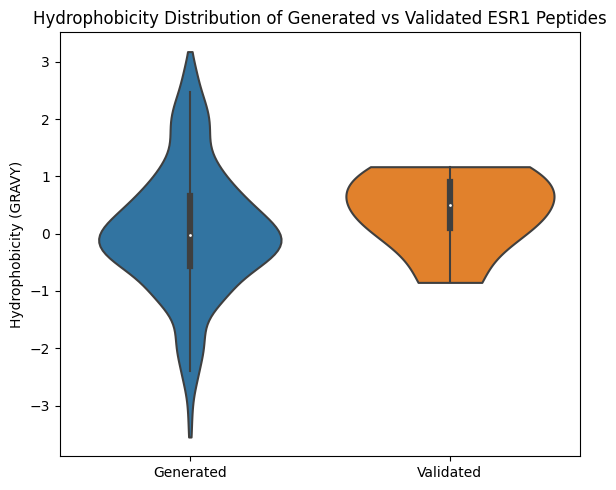

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.violinplot(
    data=df_all,
    x="Source",
    y="gravy",
    inner="box",   # shows median + IQR
    cut=0
)

plt.ylabel("Hydrophobicity (GRAVY)")
plt.xlabel("")
plt.title("Hydrophobicity Distribution of Generated vs Validated ESR1 Peptides")
plt.tight_layout()
plt.show()


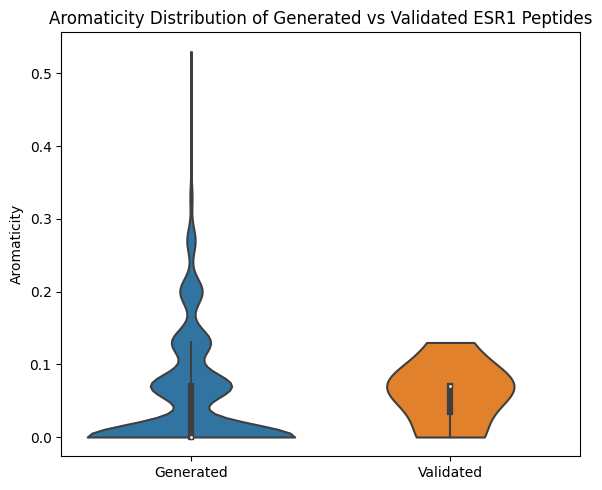

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.violinplot(
    data=df_all,
    x="Source",
    y="aromaticity",
    inner="box",   # shows median + IQR
    cut=0
)

plt.ylabel("Aromaticity")
plt.xlabel("")
plt.title("Aromaticity Distribution of Generated vs Validated ESR1 Peptides")
plt.tight_layout()
plt.show()


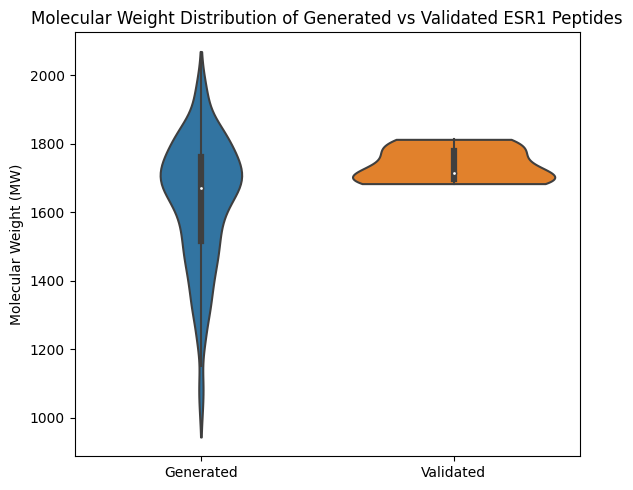

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.violinplot(
    data=df_all,
    x="Source",
    y="mw",
    inner="box",   # shows median + IQR
    cut=0
)

plt.ylabel("Molecular Weight (MW)")
plt.xlabel("")
plt.title("Molecular Weight Distribution of Generated vs Validated ESR1 Peptides")
plt.tight_layout()
plt.show()


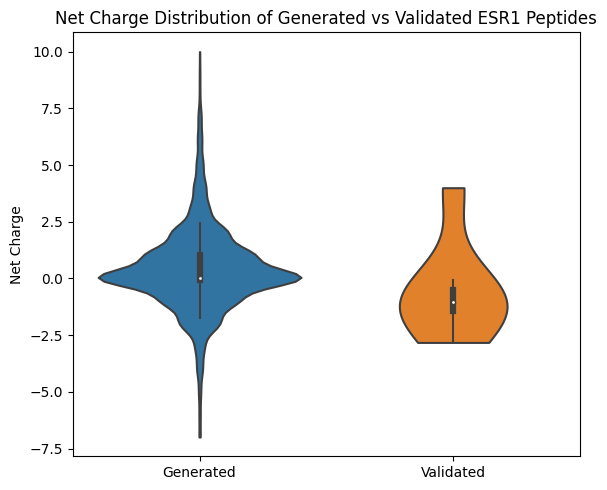

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.violinplot(
    data=df_all,
    x="Source",
    y="net_charge",
    inner="box",   # shows median + IQR
    cut=0
)

plt.ylabel("Net Charge")
plt.xlabel("")
plt.title("Net Charge Distribution of Generated vs Validated ESR1 Peptides")
plt.tight_layout()
plt.show()


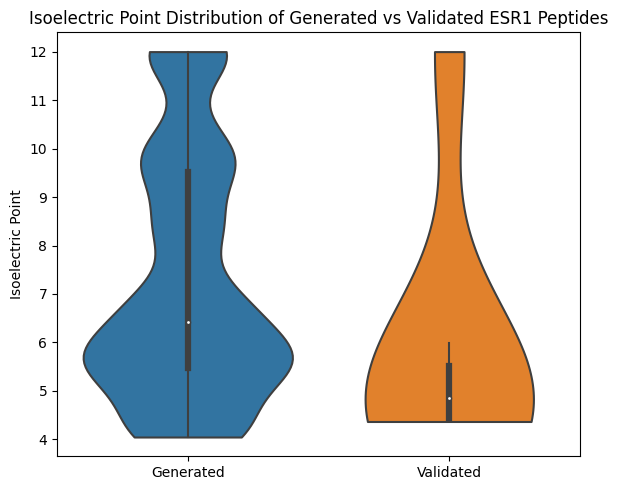

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.violinplot(
    data=df_all,
    x="Source",
    y="pI",
    inner="box",   # shows median + IQR
    cut=0
)

plt.ylabel("Isoelectric Point")
plt.xlabel("")
plt.title("Isoelectric Point Distribution of Generated vs Validated ESR1 Peptides")
plt.tight_layout()
plt.show()


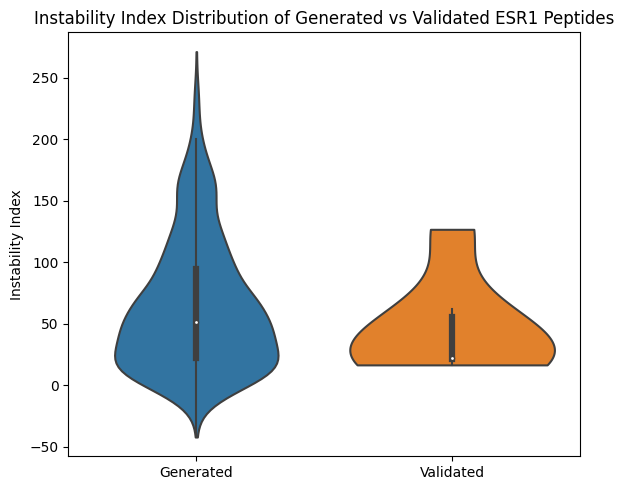

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.violinplot(
    data=df_all,
    x="Source",
    y="instability_index",
    inner="box",   # shows median + IQR
    cut=0
)

plt.ylabel("Instability Index")
plt.xlabel("")
plt.title("Instability Index Distribution of Generated vs Validated ESR1 Peptides")
plt.tight_layout()
plt.show()
